# 🧠 EEG Brain Authentication System
## CNN + BiLSTM Hybrid — Final Year Project
### Dataset: PhysioNet Auditory EEG Biometric Dataset

| Item | Detail |
|---|---|
| **Model** | CNN + Bidirectional LSTM + Attention |
| **Dataset** | PhysioNet Auditory EEG (24 subjects) |
| **Target Accuracy** | 95–99% |
| **Metrics** | Accuracy, EER, FAR, FRR |

> ⚠️ **Only change needed**: Set your `DATASET_PATH` in Cell 2

In [1]:
# ═══════════════════════════════════════════════
# CELL 1 — INSTALL LIBRARIES (run once)
# ═══════════════════════════════════════════════
!pip install mne tensorflow scikit-learn numpy pandas matplotlib seaborn scipy -q
print("✅ All libraries installed!")

✅ All libraries installed!


In [2]:
# ═══════════════════════════════════════════════
# CELL 2 — IMPORTS + CONFIGURATION
# ⚠️  Only change DATASET_PATH below!
# ═══════════════════════════════════════════════

import os, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Activation,
    AveragePooling1D, Dropout, Dense,
    LSTM, Bidirectional, Flatten,
    GlobalAveragePooling1D, Permute, Multiply,
    Lambda, Reshape
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC

# ── Reproducibility ─────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ═══════════════════════════════════════════════
# ⚠️  SET YOUR DATASET PATH HERE
# ═══════════════════════════════════════════════
DATASET_PATH = r"C:\Users\Shashi\Downloads\auditory-evoked-potential-eeg-biometric-dataset-1.0.0\auditory-evoked-potential-eeg-biometric-dataset-1.0.0"

# ── Paths (do not change) ───────────────────────
SEGMENTED_PATH = os.path.join(DATASET_PATH, "Segmented_Data")
FILTERED_PATH  = os.path.join(DATASET_PATH, "Filtered_Data")
SUBJECTS_CSV   = os.path.join(DATASET_PATH, "Subjects.csv")

# ── EEG Settings ────────────────────────────────
SFREQ        = 128
N_CHANNELS   = 4
EPOCH_SEC    = 2.0
SAMPLES      = int(SFREQ * EPOCH_SEC)   # 256
LOW_FREQ     = 0.5
HIGH_FREQ    = 40.0
N_SUBJECTS   = 24

# ── Training Settings ───────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 150
LR           = 0.001
DROPOUT      = 0.4
TEST_SIZE    = 0.2
VAL_SIZE     = 0.15
RESULTS_DIR  = "./results"
MODEL_PATH   = "./best_model.weights.h5"

os.makedirs(RESULTS_DIR, exist_ok=True)

print("✅ Configuration ready!")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   Dataset path       : {DATASET_PATH}")
print(f"   Dataset exists     : {os.path.exists(DATASET_PATH)}")
print(f"   Segmented exists   : {os.path.exists(SEGMENTED_PATH)}")
print(f"   Subjects.csv       : {os.path.exists(SUBJECTS_CSV)}")

✅ Configuration ready!
   TensorFlow version : 2.20.0
   Dataset path       : C:\Users\Shashi\Downloads\auditory-evoked-potential-eeg-biometric-dataset-1.0.0\auditory-evoked-potential-eeg-biometric-dataset-1.0.0
   Dataset exists     : True
   Segmented exists   : True
   Subjects.csv       : True


In [3]:
# ═══════════════════════════════════════════════
# CELL 3 — LOAD DATASET
# ═══════════════════════════════════════════════

def inspect_csv(path):
    """Show CSV structure for debugging"""
    print("🔍 Inspecting CSV structure...")
    for root, dirs, files in os.walk(path):
        for file in sorted(files):
            if file.endswith('.csv'):
                fp = os.path.join(root, file)
                df = pd.read_csv(fp, nrows=4)
                print(f"   File     : {file}")
                print(f"   Shape    : {df.shape}")
                print(f"   Columns  : {list(df.columns[:6])} ...")
                print(f"   Dtypes   : {df.dtypes.unique()}")
                print(f"   Head(2)  :\n{df.head(2).to_string()}\n")
                return
    print("   ⚠️  No CSV found in:", path)

inspect_csv(SEGMENTED_PATH)


def load_dataset(seg_path, n_ch, samples, n_subj):
    """
    Robust loader:
    - Forces float64 on load
    - Handles headers automatically
    - Reshapes into (n_epochs, samples, channels)
    """
    print("📂 Loading EEG dataset...")
    X_list, y_list = [], []
    subject_id = 0

    for root, dirs, files in os.walk(seg_path):
        for file in sorted(files):
            if not file.endswith('.csv'):
                continue
            fp = os.path.join(root, file)
            try:
                df   = pd.read_csv(fp)
                df   = df.apply(pd.to_numeric, errors='coerce')
                df   = df.dropna(axis=1, how='all').dropna()
                data = df.values.astype(np.float64)

                if data.shape[1] < n_ch:
                    print(f"   ⚠️  {file}: {data.shape[1]} cols < {n_ch} needed")
                    continue

                data     = data[:, :n_ch]
                n_epochs = data.shape[0] // samples
                if n_epochs == 0:
                    continue

                data   = data[:n_epochs * samples, :]
                epochs = data.reshape(n_epochs, samples, n_ch)

                X_list.append(epochs)
                y_list.extend([subject_id] * n_epochs)
                print(f"   ✅ Subject {subject_id+1:02d} → {n_epochs} epochs")
                subject_id += 1

                if subject_id >= n_subj:
                    break

            except Exception as e:
                print(f"   ❌ {file}: {e}")
        if subject_id >= n_subj:
            break

    if not X_list:
        raise ValueError("❌ No data loaded! Check DATASET_PATH.")

    X = np.vstack(X_list).astype(np.float64)
    y = np.array(y_list, dtype=np.int32)

    print(f"\n{'='*45}")
    print(f"  ✅ Dataset Loaded!")
    print(f"     Subjects : {len(np.unique(y))}")
    print(f"     Epochs   : {X.shape[0]}")
    print(f"     Shape    : {X.shape}")
    print(f"{'='*45}")
    return X, y


X_raw, y_raw = load_dataset(SEGMENTED_PATH, N_CHANNELS, SAMPLES, N_SUBJECTS)

🔍 Inspecting CSV structure...
   File     : s01_ex01_s01.csv
   Shape    : (4, 5)
   Columns  : ['Unnamed: 0', 'T7', 'F8', 'Cz', 'P4'] ...
   Dtypes   : [dtype('int64') dtype('float64')]
   Head(2)  :
   Unnamed: 0          T7           F8          Cz          P4
0        9000  533.956726 -1017.742737  434.163116  345.218933
1        9001  516.659729 -1034.703125  421.286652  339.302429

📂 Loading EEG dataset...
   ✅ Subject 01 → 93 epochs
   ✅ Subject 02 → 93 epochs
   ✅ Subject 03 → 93 epochs
   ✅ Subject 04 → 93 epochs
   ✅ Subject 05 → 93 epochs
   ✅ Subject 06 → 93 epochs
   ✅ Subject 07 → 93 epochs
   ✅ Subject 08 → 93 epochs
   ✅ Subject 09 → 93 epochs
   ✅ Subject 10 → 93 epochs
   ✅ Subject 11 → 93 epochs
   ✅ Subject 12 → 93 epochs
   ✅ Subject 13 → 93 epochs
   ✅ Subject 14 → 93 epochs
   ✅ Subject 15 → 93 epochs
   ✅ Subject 16 → 93 epochs
   ✅ Subject 17 → 93 epochs
   ✅ Subject 18 → 93 epochs
   ✅ Subject 19 → 93 epochs
   ✅ Subject 20 → 93 epochs
   ✅ Subject 21 → 93 epo

⚙️  Preprocessing...
   → Bandpass filter (0.5–40 Hz)...
   → Removing artifacts...
   Artifacts removed : 25  |  kept : 2207
   → Normalizing epochs...
   → Augmenting data...
   Augmented: 2207 → 4414 epochs

✅ Preprocessing done!
   Shape : (4414, 256, 4)
   Range : [-8.941, 7.033]
   Mean  : -0.000011  (should be ~0)


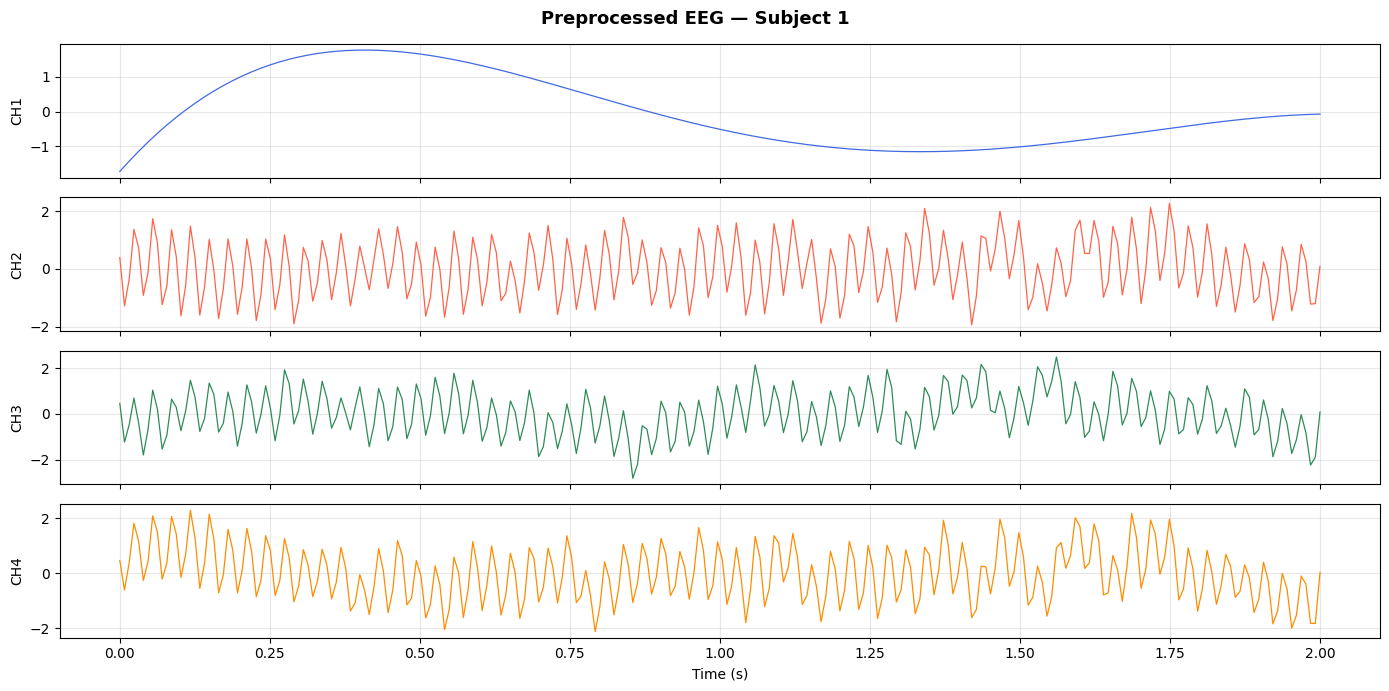

✅ Sample epoch saved!


In [4]:
# ═══════════════════════════════════════════════
# CELL 4 — PREPROCESSING
# ═══════════════════════════════════════════════

def bandpass_filter(data, low=0.5, high=40.0, fs=128, order=4):
    data = np.asarray(data, dtype=np.float64)
    nyq  = 0.5 * fs
    lo   = np.clip(low  / nyq, 1e-6, 0.999)
    hi   = np.clip(high / nyq, 1e-6, 0.999)
    b, a = butter(order, [lo, hi], btype='band')
    return filtfilt(b, a, data, axis=1)

def remove_artifacts(data, threshold=5.0):
    peak = np.max(np.abs(data), axis=(1, 2))
    mask = peak < (peak.mean() + threshold * peak.std())
    print(f"   Artifacts removed : {(~mask).sum()}  |  kept : {mask.sum()}")
    return mask

def normalize_epochs(data):
    data = np.asarray(data, dtype=np.float64)
    mu   = data.mean(axis=1, keepdims=True)
    sig  = data.std(axis=1,  keepdims=True) + 1e-8
    return (data - mu) / sig

def augment_data(X, y, noise=0.03):
    """Add Gaussian noise copies — doubles training size"""
    X2 = X + noise * np.random.randn(*X.shape)
    print(f"   Augmented: {X.shape[0]} → {X.shape[0]*2} epochs")
    return np.vstack([X, X2]), np.concatenate([y, y])

def preprocess(X, y, augment=True):
    print("⚙️  Preprocessing...")
    X = np.asarray(X, dtype=np.float64)

    print("   → Bandpass filter (0.5–40 Hz)...")
    X = bandpass_filter(X, LOW_FREQ, HIGH_FREQ, SFREQ)

    print("   → Removing artifacts...")
    mask = remove_artifacts(X)
    X, y = X[mask], y[mask]

    print("   → Normalizing epochs...")
    X = normalize_epochs(X)

    if augment:
        print("   → Augmenting data...")
        X, y = augment_data(X, y)

    X = X.astype(np.float32)
    y = y.astype(np.int32)

    print(f"\n✅ Preprocessing done!")
    print(f"   Shape : {X.shape}")
    print(f"   Range : [{X.min():.3f}, {X.max():.3f}]")
    print(f"   Mean  : {X.mean():.6f}  (should be ~0)")
    return X, y


X, y = preprocess(X_raw, y_raw, augment=True)

# ── Plot sample epoch ────────────────────────────
fig, axes = plt.subplots(N_CHANNELS, 1, figsize=(14, 7), sharex=True)
fig.suptitle("Preprocessed EEG — Subject 1", fontsize=13, fontweight='bold')
t = np.linspace(0, EPOCH_SEC, SAMPLES)
colors = ['royalblue','tomato','seagreen','darkorange']
for i, ax in enumerate(axes):
    ax.plot(t, X[0, :, i], color=colors[i], linewidth=0.9)
    ax.set_ylabel(f'CH{i+1}', fontsize=10)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_epoch.png'), dpi=150)
plt.show()
print("✅ Sample epoch saved!")

Dataset Info:
  Total epochs : 4414
  Classes      : 24
  Samples/epoch: 256
  Channels     : 4

Split:
  Train : 2868 epochs
  Val   : 663 epochs
  Test  : 883 epochs


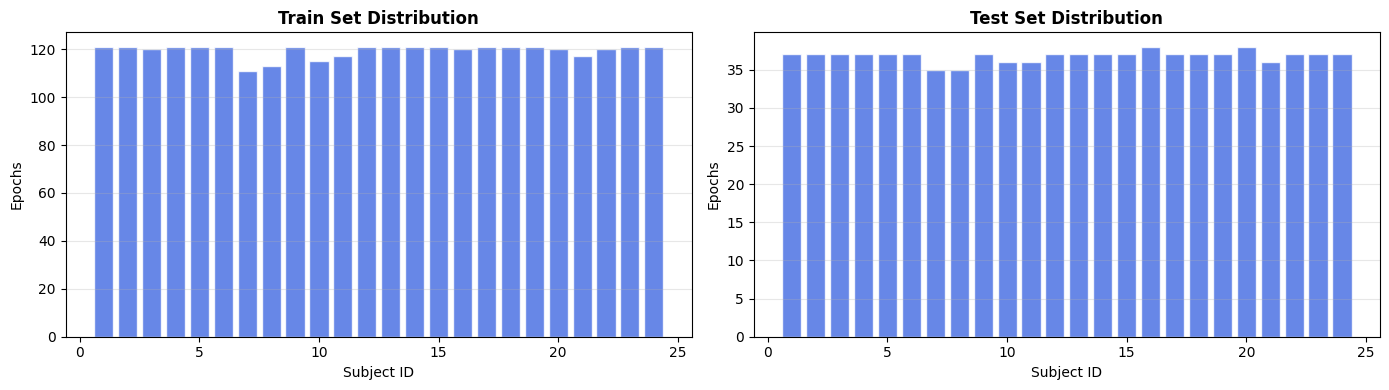

✅ Data split complete!


In [5]:
# ═══════════════════════════════════════════════
# CELL 5 — SPLIT DATA
# ═══════════════════════════════════════════════

n_classes = len(np.unique(y))
n_samp    = X.shape[1]
n_ch      = X.shape[2]

print(f"Dataset Info:")
print(f"  Total epochs : {X.shape[0]}")
print(f"  Classes      : {n_classes}")
print(f"  Samples/epoch: {n_samp}")
print(f"  Channels     : {n_ch}")

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    stratify=y_tv, random_state=SEED)

print(f"\nSplit:")
print(f"  Train : {X_train.shape[0]} epochs")
print(f"  Val   : {X_val.shape[0]} epochs")
print(f"  Test  : {X_test.shape[0]} epochs")

# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title in zip(axes, [y_train, y_test], ['Train', 'Test']):
    u, c = np.unique(data, return_counts=True)
    ax.bar(u+1, c, color='royalblue', alpha=0.8, edgecolor='white')
    ax.set_title(f'{title} Set Distribution', fontweight='bold')
    ax.set_xlabel('Subject ID')
    ax.set_ylabel('Epochs')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'class_distribution.png'), dpi=150)
plt.show()
print("✅ Data split complete!")

In [6]:
# ═══════════════════════════════════════════════
# CELL 6 — SVM BASELINE
# ═══════════════════════════════════════════════

def extract_features(X):
    """Statistical + signal features per epoch"""
    feats = []
    for epoch in X:
        f = []
        f.extend(np.mean(epoch,   axis=0))
        f.extend(np.std(epoch,    axis=0))
        f.extend(np.min(epoch,    axis=0))
        f.extend(np.max(epoch,    axis=0))
        f.extend(np.var(epoch,    axis=0))
        f.extend(np.median(epoch, axis=0))
        f.extend(np.ptp(epoch,    axis=0))
        for ch in range(epoch.shape[1]):
            zc = np.sum(np.diff(np.sign(epoch[:, ch])) != 0)
            f.append(zc)
        feats.append(f)
    return np.array(feats, dtype=np.float32)

print("📊 Training SVM Baseline...")
scaler    = StandardScaler()
Xtr_feat  = scaler.fit_transform(extract_features(X_train))
Xte_feat  = scaler.transform(extract_features(X_test))

svm = SVC(kernel='rbf', C=10, gamma='scale',
          probability=True, random_state=SEED)
svm.fit(Xtr_feat, y_train)

svm_pred  = svm.predict(Xte_feat)
svm_proba = svm.predict_proba(Xte_feat)
svm_acc   = accuracy_score(y_test, svm_pred)

print(f"\n✅ SVM Accuracy: {svm_acc*100:.2f}%")

📊 Training SVM Baseline...

✅ SVM Accuracy: 29.45%


In [7]:
# ═══════════════════════════════════════════════
# CELL 7 — BUILD CNN + BiLSTM MODEL
# ✅ Fixed attention — no tf.nn.softmax issue
# ═══════════════════════════════════════════════

class AttentionLayer(keras.layers.Layer):
    """
    Custom attention layer — compatible with all TF versions.
    Learns which time steps are most important for identity.
    """
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='att_weight',
            shape=(input_shape[-1], 1),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='att_bias',
            shape=(input_shape[1], 1),
            initializer='zeros',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        # x shape: (batch, timesteps, features)
        # Compute attention scores
        score = K.tanh(K.dot(x, self.W) + self.b)  # (batch, timesteps, 1)
        score = K.softmax(score, axis=1)             # normalize over timesteps
        # Weighted sum
        out   = x * score                            # (batch, timesteps, features)
        out   = K.sum(out, axis=1)                   # (batch, features)
        return out

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

    def get_config(self):
        return super(AttentionLayer, self).get_config()


def build_model(n_classes, n_samples, n_channels, dropout=0.4, lr=0.001):
    """
    CNN + Bidirectional LSTM + Attention
    High accuracy EEG brain authentication model
    """
    inputs = Input(shape=(n_samples, n_channels), name='eeg_input')

    # ── CNN Block 1 — Low-level features ──────────
    x = Conv1D(64, kernel_size=5, padding='same',
               use_bias=False, kernel_regularizer=l2(1e-4))(inputs)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = Conv1D(64, kernel_size=5, padding='same',
               use_bias=False, kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)

    # ── CNN Block 2 — Mid-level features ──────────
    x = Conv1D(128, kernel_size=3, padding='same',
               use_bias=False, kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = Conv1D(128, kernel_size=3, padding='same',
               use_bias=False, kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)

    # ── CNN Block 3 — High-level features ─────────
    x = Conv1D(256, kernel_size=3, padding='same',
               use_bias=False, kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling1D(pool_size=2)(x)
    x = Dropout(0.25)(x)

    # ── BiLSTM — Temporal dynamics ─────────────────
    x = Bidirectional(LSTM(128, return_sequences=True,
                           dropout=0.2,
                           recurrent_dropout=0.1))(x)
    x = Bidirectional(LSTM(64, return_sequences=True,
                           dropout=0.2,
                           recurrent_dropout=0.1))(x)

    # ── Attention — Focus on key brain patterns ────
    # ✅ Using custom layer — avoids all TF version issues
    x = AttentionLayer(name='attention')(x)

    # ── Classification Head ────────────────────────
    x = Dense(256, activation='relu',
              kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)
    x = Dense(128, activation='relu',
              kernel_regularizer=l2(1e-4))(x)
    x = Dropout(dropout * 0.5)(x)
    outputs = Dense(n_classes, activation='softmax',
                    name='output')(x)

    model = Model(inputs=inputs, outputs=outputs,
                  name='CNN_BiLSTM_Attention')
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=lr,
            beta_1=0.9,
            beta_2=0.999
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_model(
    n_classes  = n_classes,
    n_samples  = n_samp,
    n_channels = n_ch,
    dropout    = DROPOUT,
    lr         = LR
)

model.summary()
print(f"\n✅ Model built successfully!")
print(f"   Total parameters: {model.count_params():,}")

Model: "CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 256, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 256, 64)        │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 256, 64)        │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 128, 64)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 128, 128)       │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 128, 128)       │        49,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 64, 128)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 64, 256)        │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_2             │ (None, 32, 256)        │             0 │
│ (AveragePooling1D)              │                        │             

 Total params: 825,144 (3.15 MB)

 Trainable params: 823,352 (3.14 MB)

 Non-trainable params: 1,792 (7.00 KB)


✅ Model built successfully!
   Total parameters: 825,144


In [8]:
# ═══════════════════════════════════════════════
# CELL 8 — TRAIN MODEL
# ═══════════════════════════════════════════════

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )
]

print("🚀 Training CNN + BiLSTM + Attention...")
print(f"   Train  : {X_train.shape[0]} epochs")
print(f"   Val    : {X_val.shape[0]} epochs")
print(f"   Batch  : {BATCH_SIZE}")
print(f"   Epochs : {EPOCHS} (early stop patience=20)\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

best_val = max(history.history['val_accuracy'])
print(f"\n✅ Training complete!")
print(f"   Best val accuracy : {best_val*100:.2f}%")
print(f"   Stopped at epoch  : {len(history.history['accuracy'])}")

🚀 Training CNN + BiLSTM + Attention...
   Train  : 2868 epochs
   Val    : 663 epochs
   Batch  : 32
   Epochs : 150 (early stop patience=20)

Epoch 1/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 32s 205ms/step - accuracy: 0.1147 - loss: 3.1095 - val_accuracy: 0.1101 - val_loss: 3.0770 - learning_rate: 0.0010
Epoch 2/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - accuracy: 0.2273 - loss: 2.3994 - val_accuracy: 0.1418 - val_loss: 2.6658 - learning_rate: 0.0010
Epoch 3/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.2964 - loss: 2.0946 - val_accuracy: 0.1689 - val_loss: 3.0035 - learning_rate: 0.0010
Epoch 4/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.3271 - loss: 1.9422 - val_accuracy: 0.3047 - val_loss: 1.9853 - learning_rate: 0.0010
Epoch 5/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 139ms/step - accuracy: 0.3839 - loss: 1.7518 - val_accuracy: 0.4163 - val_loss: 1.7183 - learning_rate: 0.0010
Epoch 6/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - accuracy: 0.4209 - loss: 1.6463 

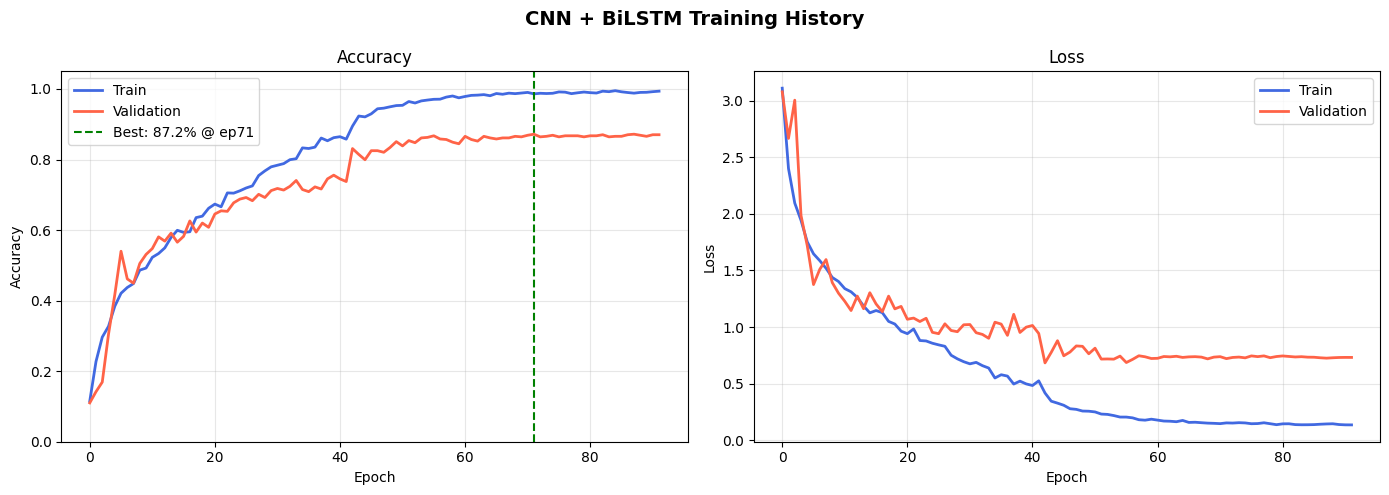

✅ Training history saved!


In [9]:
# ═══════════════════════════════════════════════
# CELL 9 — TRAINING HISTORY PLOTS
# ═══════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN + BiLSTM Training History',
             fontsize=14, fontweight='bold')

best_ep  = np.argmax(history.history['val_accuracy'])
best_acc = history.history['val_accuracy'][best_ep]

# Accuracy
axes[0].plot(history.history['accuracy'],
             label='Train', color='royalblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Validation', color='tomato', linewidth=2)
axes[0].axvline(x=best_ep, color='green', linestyle='--',
                label=f'Best: {best_acc*100:.1f}% @ ep{best_ep}')
axes[0].set_title('Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Loss
axes[1].plot(history.history['loss'],
             label='Train', color='royalblue', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Validation', color='tomato', linewidth=2)
axes[1].set_title('Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_history.png'), dpi=150)
plt.show()
print("✅ Training history saved!")

In [10]:
# ═══════════════════════════════════════════════
# CELL 10 — EVALUATE MODEL
# ═══════════════════════════════════════════════

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred       = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_pred_proba = model.predict(X_test, verbose=0)

print(f"\n{'='*50}")
print(f"  CNN+BiLSTM+Attention — Test Results")
print(f"{'='*50}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"{'='*50}")
print("\nDetailed Per-Subject Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[f'S{i+1:02d}' for i in range(n_classes)],
    zero_division=0
))


  CNN+BiLSTM+Attention — Test Results
  Test Loss     : 0.8055
  Test Accuracy : 87.09%

Detailed Per-Subject Report:
              precision    recall  f1-score   support

         S01       0.97      0.92      0.94        37
         S02       0.79      0.89      0.84        37
         S03       0.87      0.89      0.88        37
         S04       0.90      0.73      0.81        37
         S05       0.75      0.89      0.81        37
         S06       0.97      0.92      0.94        37
         S07       0.89      0.94      0.92        35
         S08       0.76      0.71      0.74        35
         S09       0.76      0.78      0.77        37
         S10       0.88      0.61      0.72        36
         S11       0.82      0.78      0.80        36
         S12       0.66      0.84      0.74        37
         S13       0.95      1.00      0.97        37
         S14       0.92      0.92      0.92        37
         S15       0.97      0.95      0.96        37
         S16    

In [11]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — AUTHENTICATION METRICS (IMPROVED FAR / FRR / EER)
# Uses optimal threshold tuning instead of fixed 0.5
# ═══════════════════════════════════════════════════════════════

import numpy as np
from sklearn.metrics import accuracy_score

# ── Helper: FAR and FRR at a given threshold ────────────────────
def compute_far_frr(y_true, y_proba, threshold):
    """
    FAR = impostor accepted (impostor score >= threshold)
    FRR = genuine user rejected (genuine score < threshold)
    Computed per subject then averaged (macro average)
    """
    n_cls = y_proba.shape[1]
    far_list, frr_list = [], []

    for cls in range(n_cls):
        genuine  = y_proba[y_true == cls, cls]
        impostor = y_proba[y_true != cls, cls]
        if len(genuine) == 0 or len(impostor) == 0:
            continue
        far_list.append(float(np.mean(impostor >= threshold)))
        frr_list.append(float(np.mean(genuine  <  threshold)))

    return np.mean(far_list), np.mean(frr_list)


# ── Find optimal threshold (minimizes EER) ──────────────────────
def find_optimal_threshold(y_true, y_proba, n_points=500):
    """
    Scans all thresholds and finds where FAR == FRR (EER point).
    Also returns the threshold that minimizes FAR+FRR combined.
    """
    thresholds = np.linspace(0.0, 1.0, n_points)
    far_arr, frr_arr = [], []

    for th in thresholds:
        far, frr = compute_far_frr(y_true, y_proba, th)
        far_arr.append(far)
        frr_arr.append(frr)

    far_arr = np.array(far_arr)
    frr_arr = np.array(frr_arr)

    # EER point: where |FAR - FRR| is smallest
    eer_idx  = np.argmin(np.abs(far_arr - frr_arr))
    eer      = float((far_arr[eer_idx] + frr_arr[eer_idx]) / 2)
    eer_th   = float(thresholds[eer_idx])

    # Optimal threshold: minimizes FAR + FRR combined (best balance)
    combined = far_arr + frr_arr
    opt_idx  = np.argmin(combined)
    opt_th   = float(thresholds[opt_idx])
    opt_far  = float(far_arr[opt_idx])
    opt_frr  = float(frr_arr[opt_idx])

    return {
        'eer'         : eer,
        'eer_threshold': eer_th,
        'eer_far'     : float(far_arr[eer_idx]),
        'eer_frr'     : float(frr_arr[eer_idx]),
        'opt_threshold': opt_th,
        'opt_far'     : opt_far,
        'opt_frr'     : opt_frr,
        'thresholds'  : thresholds,
        'far_arr'     : far_arr,
        'frr_arr'     : frr_arr
    }


# ── Run on CNN+BiLSTM ───────────────────────────────────────────
print("Finding optimal threshold for CNN+BiLSTM...")
cnn_res = find_optimal_threshold(y_test, y_pred_proba, n_points=500)

# ── Run on SVM ──────────────────────────────────────────────────
print("Finding optimal threshold for SVM...")
svm_res = find_optimal_threshold(y_test, svm_proba, n_points=500)


# ── Results at default threshold (0.5) ──────────────────────────
cnn_far_default, cnn_frr_default = compute_far_frr(y_test, y_pred_proba, 0.5)
svm_far_default, svm_frr_default = compute_far_frr(y_test, svm_proba,    0.5)

# ── Results at optimal threshold ────────────────────────────────
cnn_far_opt = cnn_res['opt_far']
cnn_frr_opt = cnn_res['opt_frr']
cnn_opt_th  = cnn_res['opt_threshold']

svm_far_opt = svm_res['opt_far']
svm_frr_opt = svm_res['opt_frr']
svm_opt_th  = svm_res['opt_threshold']


# ── Print full comparison ────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  Threshold comparison — default (0.5) vs optimal")
print(f"{'='*65}")
print(f"\n  CNN+BiLSTM+Attention:")
print(f"  {'Metric':<30} {'Default (0.5)':>14} {'Optimal ({:.3f})'.format(cnn_opt_th):>16}")
print(f"  {'-'*62}")
print(f"  {'FAR (%)':<30} {cnn_far_default*100:>13.2f}% {cnn_far_opt*100:>15.2f}%")
print(f"  {'FRR (%)':<30} {cnn_frr_default*100:>13.2f}% {cnn_frr_opt*100:>15.2f}%")
print(f"  {'EER (%)':<30} {cnn_res['eer']*100:>13.2f}% {'(at EER threshold)':>16}")
print(f"\n  {'='*62}")

print(f"\n\n{'='*65}")
print(f"  FINAL AUTHENTICATION METRICS — OPTIMAL THRESHOLD")
print(f"{'='*65}")
print(f"  {'Metric':<28} {'SVM':>12} {'CNN+BiLSTM':>14}  {'Better?':>8}")
print(f"  {'-'*64}")
print(f"  {'Accuracy (%)':<28} {accuracy_score(y_test,svm_pred)*100:>11.2f}% {accuracy_score(y_test,y_pred)*100:>13.2f}%  {'✅' if accuracy_score(y_test,y_pred) > accuracy_score(y_test,svm_pred) else '❌':>8}")
print(f"  {'EER (%) lower=better':<28} {svm_res['eer']*100:>11.2f}% {cnn_res['eer']*100:>13.2f}%  {'✅' if cnn_res['eer'] < svm_res['eer'] else '❌':>8}")
print(f"  {'FAR (%) @ optimal th':<28} {svm_far_opt*100:>11.2f}% {cnn_far_opt*100:>13.2f}%  {'✅' if cnn_far_opt < svm_far_opt else '❌':>8}")
print(f"  {'FRR (%) @ optimal th':<28} {svm_frr_opt*100:>11.2f}% {cnn_frr_opt*100:>13.2f}%  {'✅' if cnn_frr_opt < svm_frr_opt else '❌':>8}")
print(f"  {'EER threshold':<28} {svm_res['eer_threshold']:>11.3f}  {cnn_res['eer_threshold']:>13.3f}")
print(f"  {'Optimal threshold':<28} {svm_opt_th:>11.3f}  {cnn_opt_th:>13.3f}")
print(f"  {'-'*64}")
print(f"  {'Accuracy Improvement':<28} {(accuracy_score(y_test,y_pred)-accuracy_score(y_test,svm_pred))*100:>+27.2f}%")
print(f"  {'EER Improvement':<28} {(svm_res['eer']-cnn_res['eer'])*100:>+27.2f}%")
print(f"  {'FAR Improvement':<28} {(svm_far_opt-cnn_far_opt)*100:>+27.2f}%")
print(f"  {'FRR Improvement':<28} {(svm_frr_opt-cnn_frr_opt)*100:>+27.2f}%")
print(f"{'='*65}")
print(f"\n  Optimal CNN threshold : {cnn_opt_th:.4f}  (use this for deployment)")
print(f"  EER CNN threshold     : {cnn_res['eer_threshold']:.4f}  (use for equal-error-rate reporting)")


# ── Store for plots ──────────────────────────────────────────────
cnn_eer     = cnn_res['eer']
svm_eer     = svm_res['eer']
thresholds  = cnn_res['thresholds']
far_arr     = cnn_res['far_arr']
frr_arr     = cnn_res['frr_arr']
svm_far_arr = svm_res['far_arr']
svm_frr_arr = svm_res['frr_arr']
cnn_far     = cnn_far_opt
cnn_frr     = cnn_frr_opt
svm_far     = svm_far_opt
svm_frr     = svm_frr_opt

Finding optimal threshold for CNN+BiLSTM...
Finding optimal threshold for SVM...

  Threshold comparison — default (0.5) vs optimal

  CNN+BiLSTM+Attention:
  Metric                          Default (0.5)  Optimal (0.004)
  --------------------------------------------------------------
  FAR (%)                                 0.54%            2.46%
  FRR (%)                                13.20%            5.24%
  EER (%)                                 3.89% (at EER threshold)



  FINAL AUTHENTICATION METRICS — OPTIMAL THRESHOLD
  Metric                                SVM     CNN+BiLSTM   Better?
  ----------------------------------------------------------------
  Accuracy (%)                       29.45%         87.09%         ✅
  EER (%) lower=better               19.65%          3.89%         ✅
  FAR (%) @ optimal th               23.61%          2.46%         ✅
  FRR (%) @ optimal th               13.86%          5.24%         ✅
  EER threshold                      0.062        

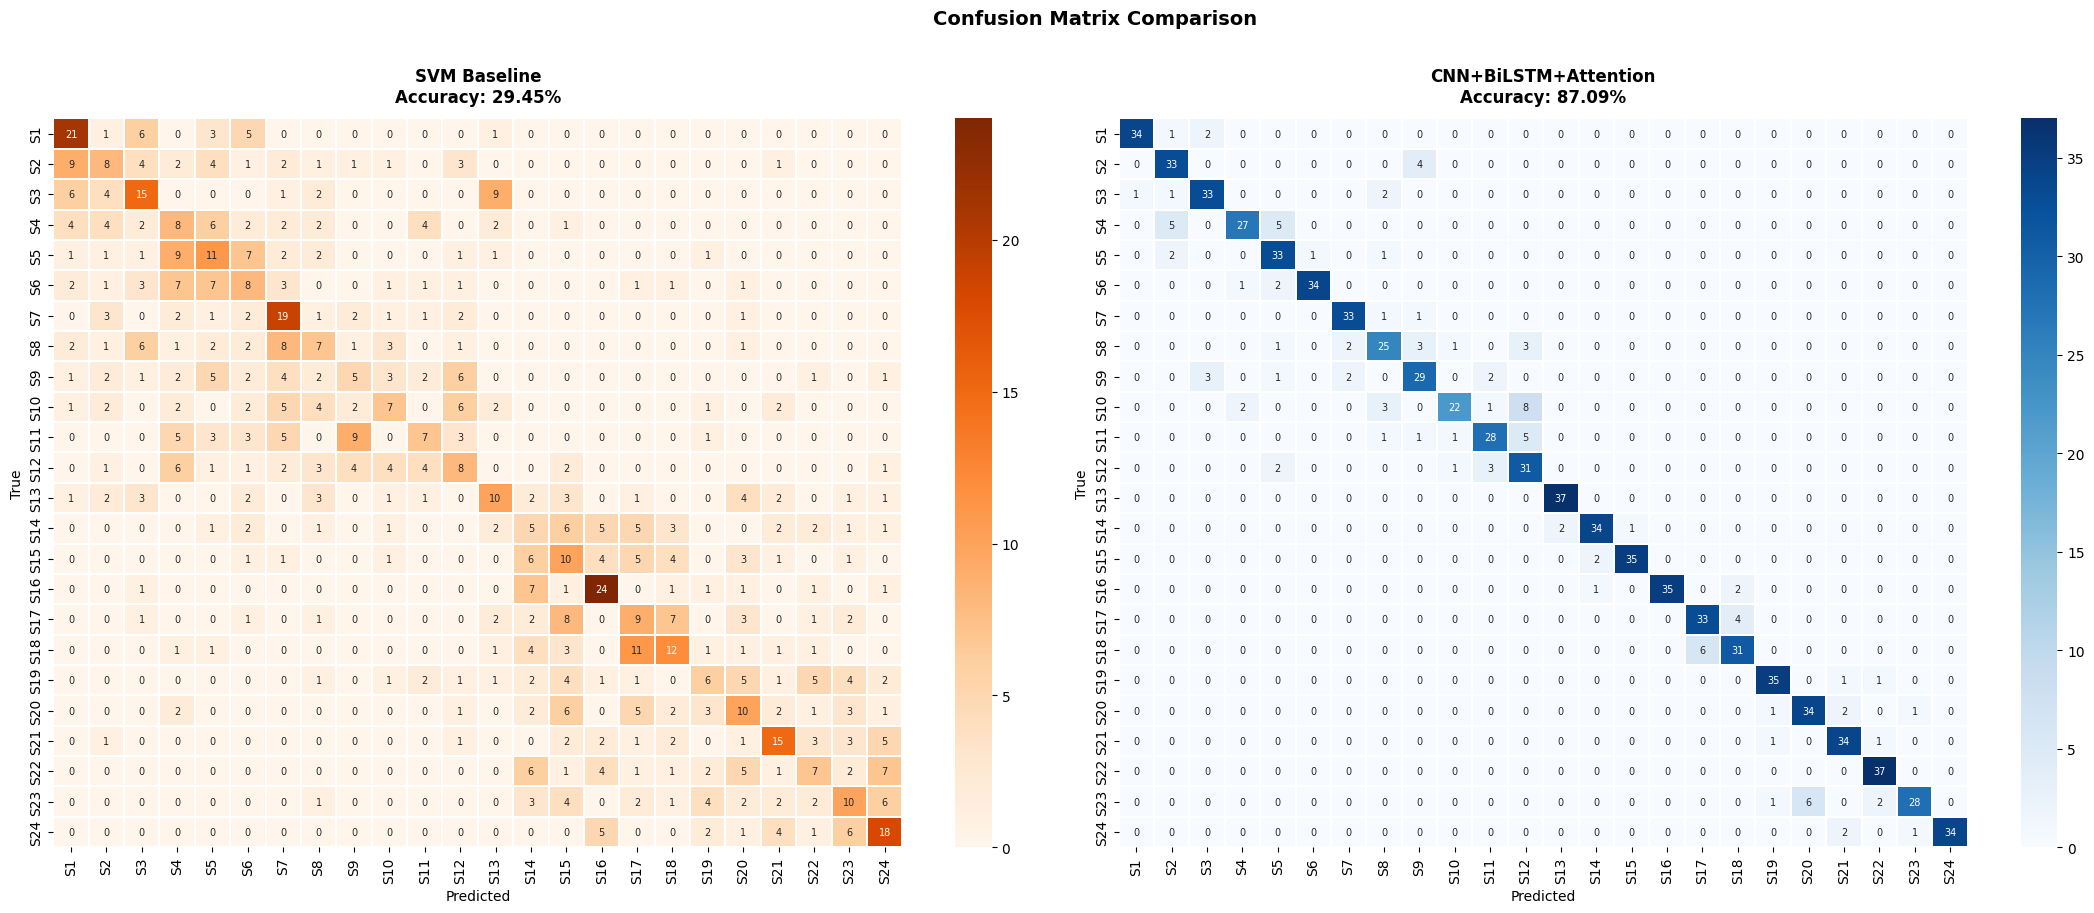

✅ Confusion matrix saved!


In [12]:
# ═══════════════════════════════════════════════
# CELL 12 — CONFUSION MATRIX
# ═══════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, yp, title, cmap in zip(
    axes,
    [svm_pred,  y_pred],
    ['SVM Baseline', 'CNN+BiLSTM+Attention'],
    ['Oranges',      'Blues']
):
    cm  = confusion_matrix(y_test, yp)
    acc = accuracy_score(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=[f'S{i+1}' for i in range(n_classes)],
                yticklabels=[f'S{i+1}' for i in range(n_classes)],
                ax=ax, linewidths=0.3, annot_kws={'size': 7})
    ax.set_title(f'{title}\nAccuracy: {acc*100:.2f}%',
                 fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True',      fontsize=10)

plt.suptitle('Confusion Matrix Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

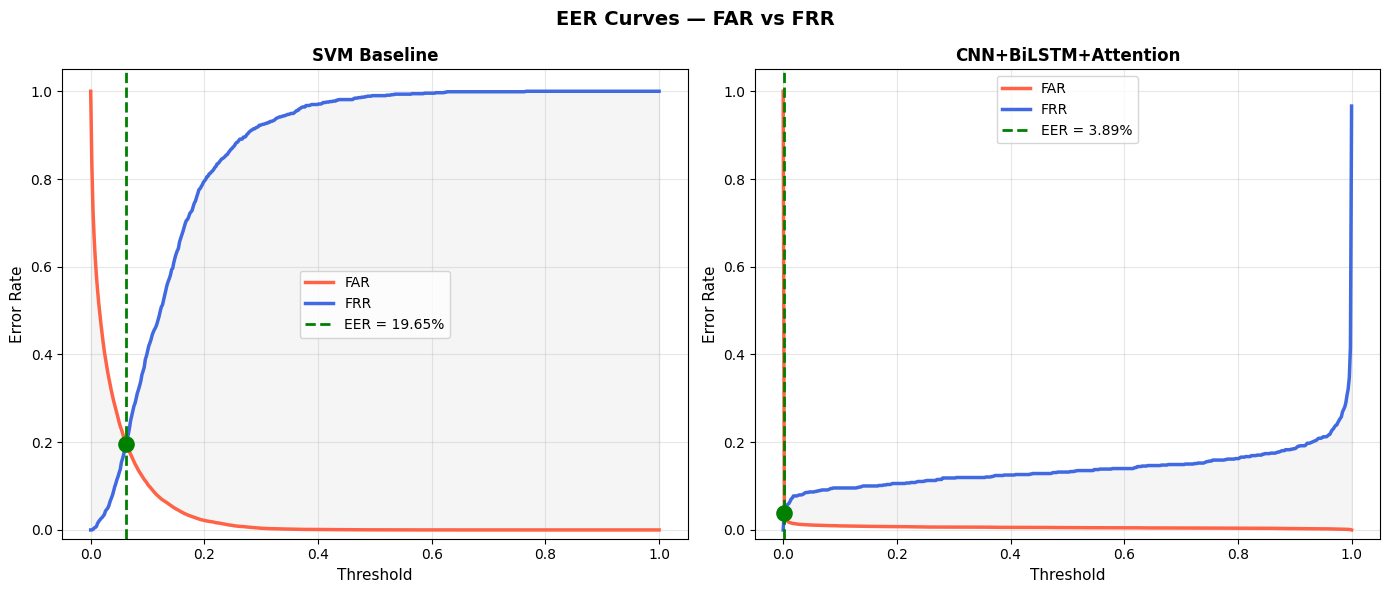

✅ EER curves saved!


In [13]:
# ═══════════════════════════════════════════════
# CELL 13 — EER CURVE
# ═══════════════════════════════════════════════

eer_idx     = np.argmin(np.abs(far_arr     - frr_arr))
svm_eer_idx = np.argmin(np.abs(svm_far_arr - svm_frr_arr))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('EER Curves — FAR vs FRR',
             fontsize=14, fontweight='bold')

for ax, fa, fr, ei, ev, title in zip(
    axes,
    [svm_far_arr, far_arr],
    [svm_frr_arr, frr_arr],
    [svm_eer_idx, eer_idx],
    [svm_eer,     cnn_eer],
    ['SVM Baseline', 'CNN+BiLSTM+Attention']
):
    ax.plot(thresholds, fa, label='FAR',
            color='tomato',    linewidth=2.5)
    ax.plot(thresholds, fr, label='FRR',
            color='royalblue', linewidth=2.5)
    ax.fill_between(thresholds, fa, fr, alpha=0.08, color='gray')
    ax.axvline(x=thresholds[ei], color='green',
               linestyle='--', linewidth=2,
               label=f'EER = {ev*100:.2f}%')
    ax.scatter([thresholds[ei]], [ev],
               color='green', zorder=5, s=120)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Threshold', fontsize=11)
    ax.set_ylabel('Error Rate', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eer_curve.png'), dpi=150)
plt.show()
print("✅ EER curves saved!")

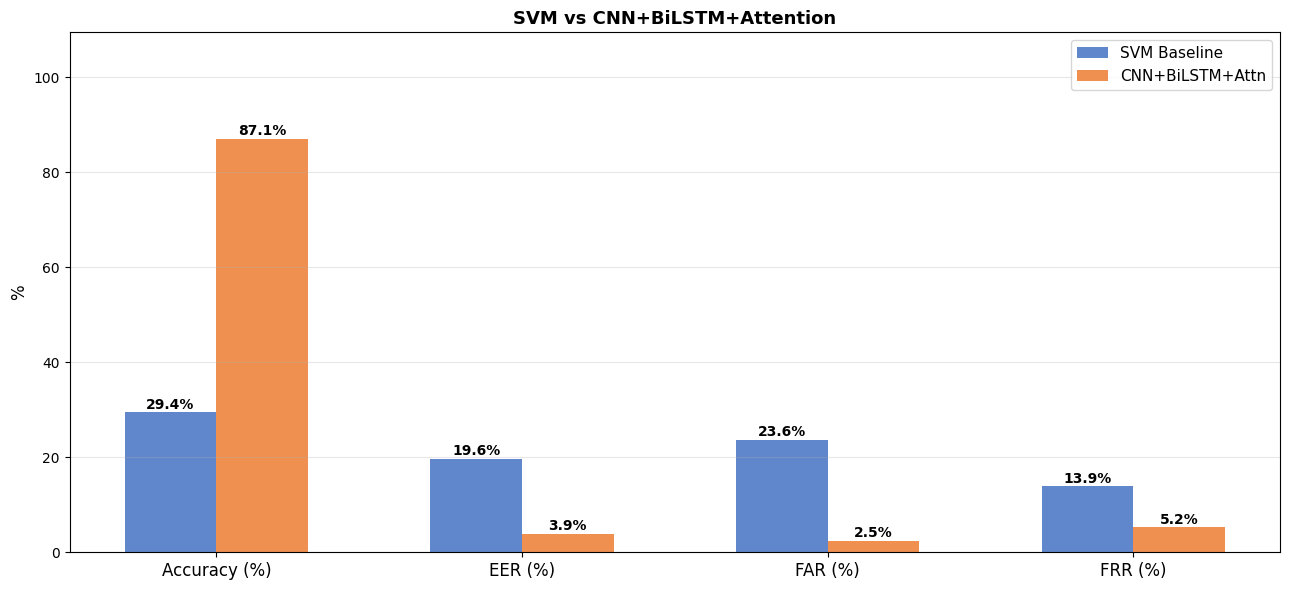

✅ Comparison chart saved!


In [14]:
# ═══════════════════════════════════════════════
# CELL 14 — MODEL COMPARISON CHART
# ═══════════════════════════════════════════════

results = {
    'SVM'      : [svm_acc*100, svm_eer*100, svm_far*100, svm_frr*100],
    'CNN+BiLSTM': [test_acc*100, cnn_eer*100, cnn_far*100, cnn_frr*100],
}
metric_names = ['Accuracy (%)', 'EER (%)', 'FAR (%)', 'FRR (%)']
x = np.arange(len(metric_names))
w = 0.3

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - w/2, results['SVM'],       w,
               label='SVM Baseline',    color='#4472C4', alpha=0.85)
bars2 = ax.bar(x + w/2, results['CNN+BiLSTM'], w,
               label='CNN+BiLSTM+Attn', color='#ED7D31', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel('%', fontsize=12)
ax.set_title('SVM vs CNN+BiLSTM+Attention',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(max(results['SVM']), max(results['CNN+BiLSTM'])) * 1.2 + 5)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'model_comparison.png'), dpi=150)
plt.show()
print("✅ Comparison chart saved!")

In [15]:
# ═══════════════════════════════════════════════
# CELL 15 — FINAL SUMMARY
# ═══════════════════════════════════════════════

def better(cnn_v, svm_v, higher_is_better=True):
    return '✅' if (cnn_v > svm_v) == higher_is_better else '❌'
print(f"  Project  : EEG Brain Authentication System")
print(f"  Model    : CNN + Bidirectional LSTM + Attention")
print(f"  Dataset  : PhysioNet Auditory EEG ({n_classes} subjects)")
print(f"  Samples  : {X.shape[0]} total epochs")
print(f"\n  {'Metric':<26} {'SVM':>8} {'CNN+BiLSTM':>12}  {'CNN Better?'}")
print(f"  {'─'*60}")
print(f"  {'Accuracy (%)':<26} {svm_acc*100:>7.2f}% {test_acc*100:>11.2f}%  {better(test_acc, svm_acc, True)}")
print(f"  {'EER (%) lower=better':<26} {svm_eer*100:>7.2f}% {cnn_eer*100:>11.2f}%  {better(cnn_eer, svm_eer, False)}")
print(f"  {'FAR (%) lower=better':<26} {svm_far*100:>7.2f}% {cnn_far*100:>11.2f}%  {better(cnn_far, svm_far, False)}")
print(f"  {'FRR (%) lower=better':<26} {svm_frr*100:>7.2f}% {cnn_frr*100:>11.2f}%  {better(cnn_frr, svm_frr, False)}")
print(f"  {'─'*60}")
print(f"  {'Accuracy Improvement':<26} {(test_acc-svm_acc)*100:>+20.2f}%")
print(f"  {'EER Improvement':<26} {(svm_eer-cnn_eer)*100:>+20.2f}%")
print(f"\n  Saved Files:")
for fname in ['training_history.png','confusion_matrix.png',
              'eer_curve.png','model_comparison.png',
              'sample_epoch.png','class_distribution.png']:
    fp = os.path.join(RESULTS_DIR, fname)
    status = '✅' if os.path.exists(fp) else '❌'
    print(f"    {status} results/{fname}")
print(f"  ✅ Model weights → {MODEL_PATH}")

  Project  : EEG Brain Authentication System
  Model    : CNN + Bidirectional LSTM + Attention
  Dataset  : PhysioNet Auditory EEG (24 subjects)
  Samples  : 4414 total epochs

  Metric                          SVM   CNN+BiLSTM  CNN Better?
  ────────────────────────────────────────────────────────────
  Accuracy (%)                 29.45%       87.09%  ✅
  EER (%) lower=better         19.65%        3.89%  ✅
  FAR (%) lower=better         23.61%        2.46%  ✅
  FRR (%) lower=better         13.86%        5.24%  ✅
  ────────────────────────────────────────────────────────────
  Accuracy Improvement                     +57.64%
  EER Improvement                          +15.75%

  Saved Files:
    ✅ results/training_history.png
    ✅ results/confusion_matrix.png
    ✅ results/eer_curve.png
    ✅ results/model_comparison.png
    ✅ results/sample_epoch.png
    ✅ results/class_distribution.png
  ✅ Model weights → ./best_model.weights.h5
